# 🏭 Case Study: Cleaning a Genuinely Messy Dataset (Industry Workflow)

**Goal:** show the *real* day-to-day workflow of a ML engineer — take a raw, messy export
(customer churn data, the kind you'd get dumped from a CRM/database), and take it all the way from
"unusable" to "model-ready", using the techniques from **Part 1** (missing values, outliers,
scaling, encoding) and **Part 2** (dtypes, duplicates, feature engineering, imbalance, safe CV).

The dataset below is generated to be deliberately messy in the exact ways real exports usually are:

- Dates and money stored as inconsistent text
- Missing values scattered non-randomly across columns
- Duplicate customer records
- Inconsistent category casing/spacing (`"Month-to-month"` vs `"MONTH-TO-MONTH"`)
- Impossible outlier values (negative tenure, age = 150)
- A skewed numeric column
- An imbalanced target (most customers don't churn)

We'll go through this in the actual order an ML engineer would work:

1. Load & look (mini-EDA)
2. Fix structural issues (dtypes, duplicates)
3. Handle missing values
4. Handle outliers
5. Feature engineering
6. Encode categoricals
7. Scale numeric features
8. Handle target imbalance
9. Build a leak-free pipeline, train a model, evaluate


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
%matplotlib inline
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
np.random.seed(42)

print("Libraries loaded ✅")


Libraries loaded ✅


## Step 0 — Generate the messy dataset

(In a real job this would be `pd.read_csv("crm_export.csv")` — here we simulate it so the notebook
is fully self-contained and reproducible for you to practice with.)


In [2]:
n = 2000

# Core signal - we build a "real" underlying relationship first, then corrupt it to look messy
tenure_true = np.random.exponential(scale=24, size=n).clip(0, 72)
age_true = np.random.normal(45, 15, size=n).clip(18, 90)
monthly_true = np.random.normal(70, 30, size=n).clip(15, 150)
contract = np.random.choice(["month-to-month", "one year", "two year"], size=n, p=[0.6, 0.25, 0.15])
payment = np.random.choice(["Electronic check", "Mailed check", "Bank transfer", "Credit card"], size=n)
gender = np.random.choice(["Male", "Female"], size=n)

# Churn probability genuinely depends on tenure/contract (short tenure + month-to-month -> more likely to churn)
churn_prob = 0.6 - (tenure_true / 100) - (contract == "two year") * 0.3 - (contract == "one year") * 0.15
churn_prob = np.clip(churn_prob, 0.02, 0.95)
churn = np.random.binomial(1, churn_prob)

df = pd.DataFrame({
    "customer_id": np.arange(1, n + 1),
    "signup_date": pd.date_range("2019-01-01", periods=n, freq="17h"),
    "age": age_true,
    "gender": gender,
    "tenure_months": tenure_true,
    "monthly_charges": monthly_true,
    "contract_type": contract,
    "payment_method": payment,
    "churn": churn,
})
df["total_charges"] = df["tenure_months"] * df["monthly_charges"] * np.random.normal(1, 0.05, size=n)

# ---------------------------------------------------------------
# Now deliberately MESS IT UP the way real CRM exports usually are messy
# ---------------------------------------------------------------

# 1. Dates: convert to inconsistent text formats
def messy_date(d):
    fmt = np.random.choice(["%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y"])
    return d.strftime(fmt)
df["signup_date"] = df["signup_date"].apply(messy_date)

# 2. Money columns: store as text with $ signs and commas
df["monthly_charges"] = df["monthly_charges"].round(2).apply(lambda x: f"${x:,.2f}")
df["total_charges"] = df["total_charges"].round(2)

# 3. Inconsistent category casing/spacing
def mess_case(x):
    choice = np.random.choice(["upper", "title", "lower_spaced", "keep"])
    if choice == "upper":
        return x.upper()
    elif choice == "title":
        return x.title()
    elif choice == "lower_spaced":
        return f" {x} "
    return x
df["contract_type"] = df["contract_type"].apply(mess_case)
df["gender"] = df["gender"].apply(lambda g: g.lower() if np.random.rand() < 0.3 else g)

# 4. Inject missing values (not uniformly - some columns are messier than others, like real data)
for col, frac in [("age", 0.08), ("total_charges", 0.05), ("payment_method", 0.03), ("gender", 0.02)]:
    missing_idx = np.random.choice(df.index, size=int(n * frac), replace=False)
    df.loc[missing_idx, col] = np.nan

# 5. Inject impossible/outlier values (data entry errors)
outlier_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[outlier_idx[:5], "age"] = np.random.choice([150, 200, -5], size=5)
df.loc[outlier_idx[5:10], "tenure_months"] = -np.random.randint(1, 10, size=5)
df.loc[outlier_idx[10:], "monthly_charges"] = "$99999.00"

# 6. Inject duplicate customer records (common when systems merge)
duplicate_rows = df.sample(30, random_state=1)
df = pd.concat([df, duplicate_rows], ignore_index=True)

# Shuffle so duplicates aren't suspiciously at the bottom
df = df.sample(frac=1, random_state=7).reset_index(drop=True)

print("Messy dataset created. Shape:", df.shape)
df.head(10)


Messy dataset created. Shape: (2030, 10)


,customer_id,signup_date,age,gender,tenure_months,monthly_charges,contract_type,payment_method,churn,total_charges
0,1847,31/07/2022,NaN,Female,3.108983,$15.00,MONTH-TO-MONTH,Bank transfer,0,45.91
1,1472,2021-11-07,NaN,female,32.187043,$22.02,MONTH-TO-MONTH,Credit card,0,725.25
2,1779,06-13-2022,58.706574,Male,7.054297,$53.84,MONTH-TO-MONTH,Bank transfer,1,403.69
3,1412,2021-09-26,29.151635,female,2.848633,$79.27,MONTH-TO-MONTH,Credit card,1,229.12
4,387,01/10/2019,61.286795,Female,7.952013,$59.52,MONTH-TO-MONTH,NaN,1,501.95
5,351,09-05-2019,62.596870,Female,16.786547,$120.07,month-to-month,Electronic check,1,1976.54
6,312,08-09-2019,18.772020,female,1.960924,$63.53,one year,Mailed check,0,120.34
7,1932,2022-09-29,44.037238,male,19.784648,$71.10,MONTH-TO-MONTH,Electronic check,1,1401.66
8,841,18/08/2020,22.552061,Female,0.316343,$79.73,Month-To-Month,Credit card,0,23.55
9,493,15/12/2019,32.663701,male,7.796962,$97.97,one year,Electronic check,1,796.47


---
## Step 1 — Mini-EDA: Understand the damage first

Never touch a value before you know what you're dealing with. Same checklist every time.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      2030 non-null   int64  
 1   signup_date      2030 non-null   str    
 2   age              1867 non-null   float64
 3   gender           1989 non-null   str    
 4   tenure_months    2030 non-null   float64
 5   monthly_charges  2030 non-null   str    
 6   contract_type    2030 non-null   str    
 7   payment_method   1970 non-null   str    
 8   churn            2030 non-null   int64  
 9   total_charges    1927 non-null   float64
dtypes: float64(3), int64(2), str(5)
memory usage: 158.7 KB


In [4]:
df.isnull().sum().sort_values(ascending=False)


age                163
total_charges      103
payment_method      60
gender              41
signup_date          0
customer_id          0
monthly_charges      0
tenure_months        0
contract_type        0
churn                0
dtype: int64

In [5]:
print("Duplicate rows (exact):", df.duplicated().sum())
print("Duplicate customer_id:", df.duplicated(subset=['customer_id']).sum())


Duplicate rows (exact): 30
Duplicate customer_id: 30


In [6]:
# dtype problems jump out immediately: monthly_charges and signup_date are 'object' (text)
# even though they're clearly a number and a date
print(df.dtypes)
print("\nSample of 'monthly_charges' raw values:", df['monthly_charges'].sample(5, random_state=1).tolist())
print("Sample of 'signup_date' raw values:  ", df['signup_date'].sample(5, random_state=1).tolist())
print("Unique 'contract_type' values BEFORE cleaning:", df['contract_type'].unique())


customer_id          int64
signup_date            str
age                float64
gender                 str
tenure_months      float64
monthly_charges        str
contract_type          str
payment_method         str
churn                int64
total_charges      float64
dtype: object

Sample of 'monthly_charges' raw values: ['$36.22', '$79.23', '$63.07', '$15.79', '$29.42']
Sample of 'signup_date' raw values:   ['2020-04-10', '2020-02-10', '2020-12-07', '07-03-2022', '2020-11-03']
Unique 'contract_type' values BEFORE cleaning: <StringArray>
[  'MONTH-TO-MONTH',   'month-to-month',         'one year',
   'Month-To-Month', ' month-to-month ',         'One Year',
         'two year',         'ONE YEAR',       ' one year ',
         'Two Year',       ' two year ',         'TWO YEAR']
Length: 12, dtype: str


In [7]:
# Quick look at numeric spread - age and tenure both show impossible values
df[["age", "tenure_months"]].describe()


,age,tenure_months
count,1867.000000,2030.000000
mean,45.525315,22.761925
std,15.375738,20.213872
min,-5.000000,-7.000000
25%,35.160673,6.516289
50%,45.187490,16.918993
75%,55.300382,33.259869
max,200.000000,72.000000


**Diagnosis (this is the thinking, not just the code):**

- `monthly_charges` is text with `$` and commas → needs type fixing before it can be used at all
- `signup_date` is text in 3 different formats → needs parsing
- `contract_type` has the same 3 real categories hidden behind casing/spacing noise → needs standardizing
- `age` has impossible values (150, 200, -5) and `tenure_months` has negative values → outliers/errors
- `age`, `total_charges`, `payment_method`, `gender` have missing values, in different amounts → each needs its own imputation decision
- There are duplicate `customer_id`s → needs deduplication
- `churn` (target) is likely imbalanced → must check before modeling

This matches exactly the order we'll fix things in — structural issues first, then missing values,
then outliers, because you can't reliably impute or detect outliers in a column that's still text.


---
## Step 2 — Fix Structural Issues (dtypes & duplicates) — *Part 2, Section 1*


In [8]:
clean = df.copy()

# --- Fix monthly_charges: strip $ and commas, convert to float ---
clean["monthly_charges"] = (
    clean["monthly_charges"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# --- Fix signup_date: parse mixed formats, invalid ones become NaT rather than crashing ---
clean["signup_date"] = pd.to_datetime(clean["signup_date"], format="mixed", errors="coerce")

# --- Standardize categorical text: strip whitespace + lowercase BEFORE anything else touches them ---
clean["contract_type"] = clean["contract_type"].str.strip().str.lower()
clean["gender"] = clean["gender"].str.strip().str.lower()

print("Unique 'contract_type' values AFTER cleaning:", clean["contract_type"].unique())
print("dtypes now:\n", clean[["monthly_charges", "signup_date"]].dtypes)


Unique 'contract_type' values AFTER cleaning: <StringArray>
['month-to-month', 'one year', 'two year']
Length: 3, dtype: str
dtypes now:
 monthly_charges           float64
signup_date        datetime64[us]
dtype: object


In [9]:
# --- Remove duplicate customer records ---
print("Shape before dedup:", clean.shape)
clean = clean.drop_duplicates(subset=["customer_id"], keep="first")
print("Shape after dedup: ", clean.shape)
print("Remaining duplicate customer_id:", clean.duplicated(subset=["customer_id"]).sum())


Shape before dedup: (2030, 10)
Shape after dedup:  (2000, 10)
Remaining duplicate customer_id: 0


---
## Step 3 — Handle Outliers — *Part 1, Section 5*

`age` and `tenure_months` and `monthly_charges` each have impossible/extreme values injected. We
treat these as **data-entry errors**, not genuine rare events, so capping/removal is appropriate
here (not a judgment call you'd always make — always check with domain knowledge first).


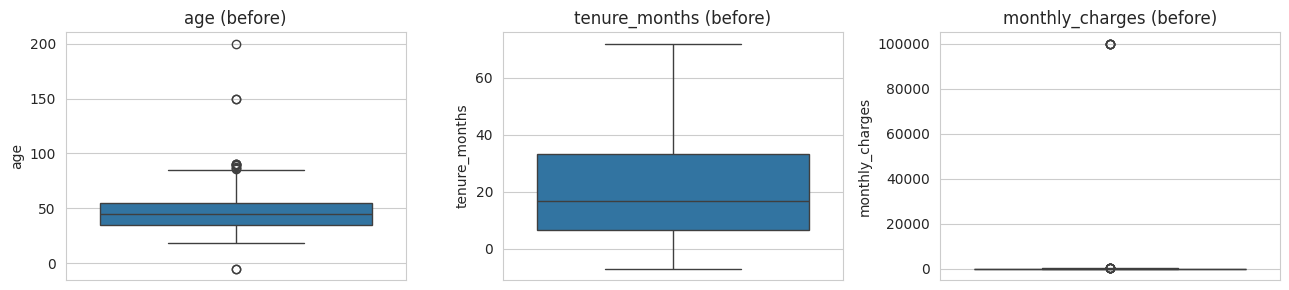

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
sns.boxplot(y=clean["age"], ax=axes[0]); axes[0].set_title("age (before)")
sns.boxplot(y=clean["tenure_months"], ax=axes[1]); axes[1].set_title("tenure_months (before)")
sns.boxplot(y=clean["monthly_charges"], ax=axes[2]); axes[2].set_title("monthly_charges (before)")
plt.tight_layout()
plt.show()


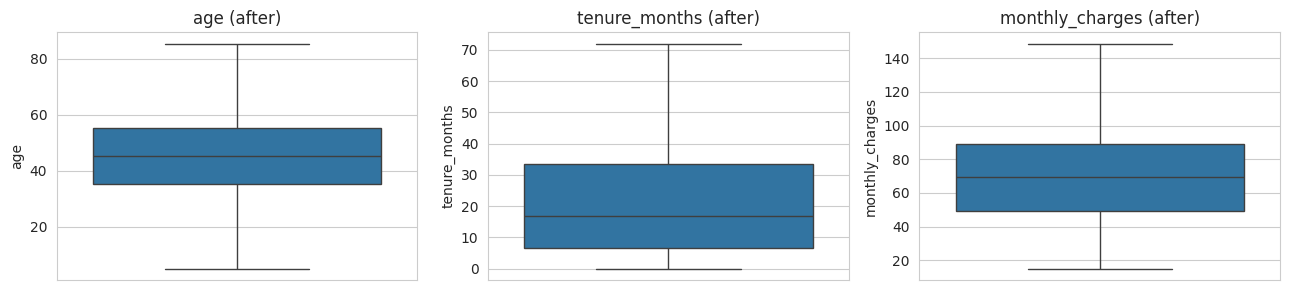

In [11]:
def cap_with_iqr(series, lower_clip=None, upper_clip=None):
    # Cap (winsorize) a series to its IQR-based bounds, with optional hard domain limits.
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    if lower_clip is not None:
        lower = max(lower, lower_clip)
    if upper_clip is not None:
        upper = min(upper, upper_clip)
    return series.clip(lower=lower, upper=upper)

# age: also apply a hard domain limit (nobody is a negative age or 150 years old)
clean["age"] = cap_with_iqr(clean["age"], lower_clip=0, upper_clip=100)

# tenure_months: can't be negative by definition - hard floor at 0, cap upper via IQR
clean["tenure_months"] = cap_with_iqr(clean["tenure_months"], lower_clip=0)

# monthly_charges: cap the extreme $99999 entry using IQR bounds
clean["monthly_charges"] = cap_with_iqr(clean["monthly_charges"])

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
sns.boxplot(y=clean["age"], ax=axes[0]); axes[0].set_title("age (after)")
sns.boxplot(y=clean["tenure_months"], ax=axes[1]); axes[1].set_title("tenure_months (after)")
sns.boxplot(y=clean["monthly_charges"], ax=axes[2]); axes[2].set_title("monthly_charges (after)")
plt.tight_layout()
plt.show()


---
## Step 4 — Handle Missing Values — *Part 1, Section 4*

Different columns get different treatment based on what they are and how much is missing.


In [12]:
clean.isnull().sum().sort_values(ascending=False)


age                160
total_charges      100
payment_method      60
gender              40
signup_date          0
customer_id          0
monthly_charges      0
tenure_months        0
contract_type        0
churn                0
dtype: int64

In [13]:
# age: numeric, moderate missingness, roughly symmetric after outlier capping -> median is safe
clean["age"] = clean["age"].fillna(clean["age"].median())

# total_charges: numeric, likely skewed (it's a product of tenure * monthly charges) -> median again
clean["total_charges"] = clean["total_charges"].fillna(clean["total_charges"].median())

# payment_method / gender: categorical, small amount missing -> mode imputation
clean["payment_method"] = clean["payment_method"].fillna(clean["payment_method"].mode()[0])
clean["gender"] = clean["gender"].fillna(clean["gender"].mode()[0])

print("Missing values remaining:\n", clean.isnull().sum().sort_values(ascending=False))


Missing values remaining:
 customer_id        0
signup_date        0
age                0
gender             0
tenure_months      0
monthly_charges    0
contract_type      0
payment_method     0
churn              0
total_charges      0
dtype: int64


---
## Step 5 — Feature Engineering — *Part 2, Section 2*

Now that the raw columns are clean and typed correctly, we can build genuinely useful new features.


In [14]:
# Date -> useful parts
clean["signup_year"] = clean["signup_date"].dt.year
clean["signup_month"] = clean["signup_date"].dt.month

# Ratio feature: charge per month of tenure - flags customers whose bill doesn't match their history
clean["avg_monthly_from_total"] = clean["total_charges"] / clean["tenure_months"].replace(0, 1)

# Binned tenure - sometimes a simpler grouped signal helps a model (and helps humans read reports)
clean["tenure_group"] = pd.cut(
    clean["tenure_months"], bins=[-1, 6, 12, 24, 48, 100],
    labels=["0-6mo", "6-12mo", "1-2yr", "2-4yr", "4yr+"]
)

clean[["signup_year", "signup_month", "avg_monthly_from_total", "tenure_group"]].head()


,signup_year,signup_month,avg_monthly_from_total,tenure_group
0,2022,7,14.766889,0-6mo
1,2021,11,22.532359,2-4yr
2,2022,6,57.226114,6-12mo
3,2021,9,80.431575,0-6mo
4,2019,1,63.122384,6-12mo


---
## Step 6 — Check the Target for Imbalance — *Part 2, Section 4*

Always check this **before** building any pipeline — it decides how you'll split, evaluate, and
possibly resample.


In [15]:
clean["churn"].value_counts(normalize=True).round(3)


churn
0    0.673
1    0.327
Name: proportion, dtype: float64

Roughly 60/40 here — mild-to-moderate imbalance, not severe. We'll handle it with
`class_weight="balanced"` (Part 2's simplest, safest first option) rather than SMOTE, and make
sure to use `stratify` on the split and `StratifiedKFold` for evaluation either way.


---
## Step 7 — Build the Leak-Free Pipeline (Scaling + Encoding + Model) — *Part 1 §8, Part 2 §5*

Everything from here on is packaged into one `Pipeline` + `ColumnTransformer`, so scaling and
encoding are fit **only on the training fold**, never on the full dataset.


In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model_df = clean.drop(columns=["customer_id", "signup_date"])   # drop identifiers/raw date, keep engineered parts

X = model_df.drop(columns=["churn"])
y = model_df["churn"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Numeric features: ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'signup_year', 'signup_month', 'avg_monthly_from_total']
Categorical features: ['gender', 'contract_type', 'payment_method', 'tenure_group']


In [17]:
preprocessor = ColumnTransformer(transformers=[
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

full_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

# Cross-validate the WHOLE pipeline (preprocessing refits fresh inside each fold) before final fit
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
print("Cross-val ROC-AUC per fold:", cv_scores.round(3))
print("Mean CV ROC-AUC:", round(cv_scores.mean(), 3))


Cross-val ROC-AUC per fold: [0.75  0.712 0.777 0.752 0.781]
Mean CV ROC-AUC: 0.754


In [18]:
# Final fit on the full training set, evaluate once on the untouched test set
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)
y_proba = full_pipeline.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Test ROC-AUC: 0.708

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.59      0.69       269
           1       0.47      0.76      0.58       131

    accuracy                           0.64       400
   macro avg       0.65      0.67      0.63       400
weighted avg       0.71      0.64      0.65       400



---
## Step 8 — Save the Pipeline — *Part 2, Section 6*

This one object now contains every cleaning/scaling/encoding step *and* the trained model. Any new
raw data (post structural cleaning — dtypes/outliers/missing values still need to run first, since
those are judgment calls rather than something we'd want silently baked into a black-box pipeline)
can be scored with this single object.


In [19]:
import joblib

joblib.dump(full_pipeline, "churn_model_pipeline.joblib")
print("Pipeline saved ✅")

reloaded = joblib.load("churn_model_pipeline.joblib")
print("Reloaded pipeline predicts on 5 sample rows:", reloaded.predict(X_test.head()))


Pipeline saved ✅
Reloaded pipeline predicts on 5 sample rows: [1 1 0 1 1]


---
## Recap — the exact path we took

| Step | Problem found | Technique used | Guide reference |
|---|---|---|---|
| 1 | Text-formatted money/dates | `.str.replace` + `pd.to_datetime` | Part 2 §1 |
| 1 | Inconsistent category casing | `.str.strip().str.lower()` | Part 2 §1 |
| 1 | Duplicate customer records | `drop_duplicates(subset=...)` | Part 2 §1 |
| 2 | Impossible ages/tenure/charges | IQR capping + domain limits | Part 1 §5 |
| 3 | Missing numeric/categorical values | Median / mode imputation | Part 1 §4 |
| 4 | Raw date, weak ratio signal | Date parts, ratio feature, binning | Part 2 §2 |
| 5 | Target imbalance (60/40) | `class_weight="balanced"` + stratified split/CV | Part 2 §4, §5 |
| 6 | Needed leak-free scaling/encoding | `ColumnTransformer` + `Pipeline` | Part 1 §8 |
| 7 | Needed reusable production artifact | `joblib.dump` on the whole pipeline | Part 2 §6 |

**This is the actual day-to-day loop**: look at the data, diagnose what's wrong column by column,
fix structural issues first, then missing values, then outliers, then engineer/encode/scale, then
wrap it all in a pipeline before touching a model. Every dataset you get will need a different mix
of these — but the *order* and the *reasoning* stay the same.
